<a href="https://colab.research.google.com/github/DylanSanchz/Quantum-Circuits/blob/main/Bernstein%E2%80%93Vazirani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduccion


En esta implementación se estudiará el algoritmo de Bernstein-Vazinari, uno de los algoritmos cuánticos más didactos para introducir la idea de ventaja cuántica en problemas de consulta a oráculos. Su objetivo es descubir una cadena binaria secreta "s" codificada en una funcion del tipo (insertar ecuacion) donde x y s son cadenas de bits y el producto es binario modulo 2. Mientras que en el enfoque clasico se requieren "n" consultas para determinar una cadena de "n bits", el enfoque cuantico permite recuperar la cadena secreta con una sola consulta al oráculo ideal.

Instalamos las librerias necesarias

In [ ]:
%pip install qiskit -q
%pip install qiskit-aer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 82.4 MB/s eta 0:00:00


In [ ]:
pip install 'qiskit [visualization]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=663fc1996c439550358c319787520cdd2442c1a051ce457462a1c569ea34a003
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
#Importamos la liberias

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

Cadena secreta y Circuito Cuantico

In [ ]:
# Cadena secreta
a= "11001"
n = len(a)

# Crear el circuito:
# n qubits de entrada + 1 qubit auxiliar
# n bits clásicos para la medición
qc = QuantumCircuit(n + 1, n)

# Preparamos el  qbit auxiiar
qc.x(n)
qc.barrier()

# Hadamard en todos los qubits

qc.h(range(n+1))
qc.barrier()


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=6, num_clbits=0, params=[]), qubits=(<Qubit register=(6, "q"), index=0>, <Qubit register=(6, "q"), index=1>, <Qubit register=(6, "q"), index=2>, <Qubit register=(6, "q"), index=3>, <Qubit register=(6, "q"), index=4>, <Qubit register=(6, "q"), index=5>), clbits=())

## ORACULO

In [ ]:
#Aplicamos el oraculo
# (por cada bit que vale 1, debemos poner una CNOT)
for i, bit in enumerate(reversed(a)):
    if bit == "1":
        qc.cx(i, n)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=6, num_clbits=0, params=[]), qubits=(<Qubit register=(6, "q"), index=0>, <Qubit register=(6, "q"), index=1>, <Qubit register=(6, "q"), index=2>, <Qubit register=(6, "q"), index=3>, <Qubit register=(6, "q"), index=4>, <Qubit register=(6, "q"), index=5>), clbits=())

In [ ]:
# Dibujar el circuito
print(qc.draw())

           ░ ┌───┐ ░                 ░ 
q_0: ──────░─┤ H ├─░───■─────────────░─
           ░ ├───┤ ░   │             ░ 
q_1: ──────░─┤ H ├─░───┼─────────────░─
           ░ ├───┤ ░   │             ░ 
q_2: ──────░─┤ H ├─░───┼─────────────░─
           ░ ├───┤ ░   │             ░ 
q_3: ──────░─┤ H ├─░───┼────■────────░─
           ░ ├───┤ ░   │    │        ░ 
q_4: ──────░─┤ H ├─░───┼────┼────■───░─
     ┌───┐ ░ ├───┤ ░ ┌─┴─┐┌─┴─┐┌─┴─┐ ░ 
q_5: ┤ X ├─░─┤ H ├─░─┤ X ├┤ X ├┤ X ├─░─
     └───┘ ░ └───┘ ░ └───┘└───┘└───┘ ░ 
c: 5/══════════════════════════════════
                                       


In [ ]:
# Hadamard de nuevo
qc.h(range(n+1))
qc.barrier()


# Medición de los qubits de entrada

#qc.measure(range(n), range(n))

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=6, num_clbits=0, params=[]), qubits=(<Qubit register=(6, "q"), index=0>, <Qubit register=(6, "q"), index=1>, <Qubit register=(6, "q"), index=2>, <Qubit register=(6, "q"), index=3>, <Qubit register=(6, "q"), index=4>, <Qubit register=(6, "q"), index=5>), clbits=())

In [ ]:
 #Dibujar el circuito
print(qc.draw())

           ░ ┌───┐ ░                 ░ ┌───┐ ░ 
q_0: ──────░─┤ H ├─░───■─────────────░─┤ H ├─░─
           ░ ├───┤ ░   │             ░ ├───┤ ░ 
q_1: ──────░─┤ H ├─░───┼─────────────░─┤ H ├─░─
           ░ ├───┤ ░   │             ░ ├───┤ ░ 
q_2: ──────░─┤ H ├─░───┼─────────────░─┤ H ├─░─
           ░ ├───┤ ░   │             ░ ├───┤ ░ 
q_3: ──────░─┤ H ├─░───┼────■────────░─┤ H ├─░─
           ░ ├───┤ ░   │    │        ░ ├───┤ ░ 
q_4: ──────░─┤ H ├─░───┼────┼────■───░─┤ H ├─░─
     ┌───┐ ░ ├───┤ ░ ┌─┴─┐┌─┴─┐┌─┴─┐ ░ ├───┤ ░ 
q_5: ┤ X ├─░─┤ H ├─░─┤ X ├┤ X ├┤ X ├─░─┤ H ├─░─
     └───┘ ░ └───┘ ░ └───┘└───┘└───┘ ░ └───┘ ░ 
c: 5/══════════════════════════════════════════
                                               


In [ ]:
# Medición de los qubits de entrada

qc.measure(range(n), range(n))
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=6, num_clbits=0, params=[]), qubits=(<Qubit register=(6, "q"), index=0>, <Qubit register=(6, "q"), index=1>, <Qubit register=(6, "q"), index=2>, <Qubit register=(6, "q"), index=3>, <Qubit register=(6, "q"), index=4>, <Qubit register=(6, "q"), index=5>), clbits=())

In [ ]:
#Dibujar el circuito

print(qc.draw())

           ░ ┌───┐ ░                 ░ ┌───┐ ░ ┌─┐             ░ 
q_0: ──────░─┤ H ├─░───■─────────────░─┤ H ├─░─┤M├─────────────░─
           ░ ├───┤ ░   │             ░ ├───┤ ░ └╥┘┌─┐          ░ 
q_1: ──────░─┤ H ├─░───┼─────────────░─┤ H ├─░──╫─┤M├──────────░─
           ░ ├───┤ ░   │             ░ ├───┤ ░  ║ └╥┘┌─┐       ░ 
q_2: ──────░─┤ H ├─░───┼─────────────░─┤ H ├─░──╫──╫─┤M├───────░─
           ░ ├───┤ ░   │             ░ ├───┤ ░  ║  ║ └╥┘┌─┐    ░ 
q_3: ──────░─┤ H ├─░───┼────■────────░─┤ H ├─░──╫──╫──╫─┤M├────░─
           ░ ├───┤ ░   │    │        ░ ├───┤ ░  ║  ║  ║ └╥┘┌─┐ ░ 
q_4: ──────░─┤ H ├─░───┼────┼────■───░─┤ H ├─░──╫──╫──╫──╫─┤M├─░─
     ┌───┐ ░ ├───┤ ░ ┌─┴─┐┌─┴─┐┌─┴─┐ ░ ├───┤ ░  ║  ║  ║  ║ └╥┘ ░ 
q_5: ┤ X ├─░─┤ H ├─░─┤ X ├┤ X ├┤ X ├─░─┤ H ├─░──╫──╫──╫──╫──╫──░─
     └───┘ ░ └───┘ ░ └───┘└───┘└───┘ ░ └───┘ ░  ║  ║  ║  ║  ║  ░ 
c: 5/═══════════════════════════════════════════╩══╩══╩══╩══╩════
                                                0  1  2  3  4    


In [ ]:
from qiskit import QuantumCircuit, transpile
#from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [ ]:
!pip install pylatexenc

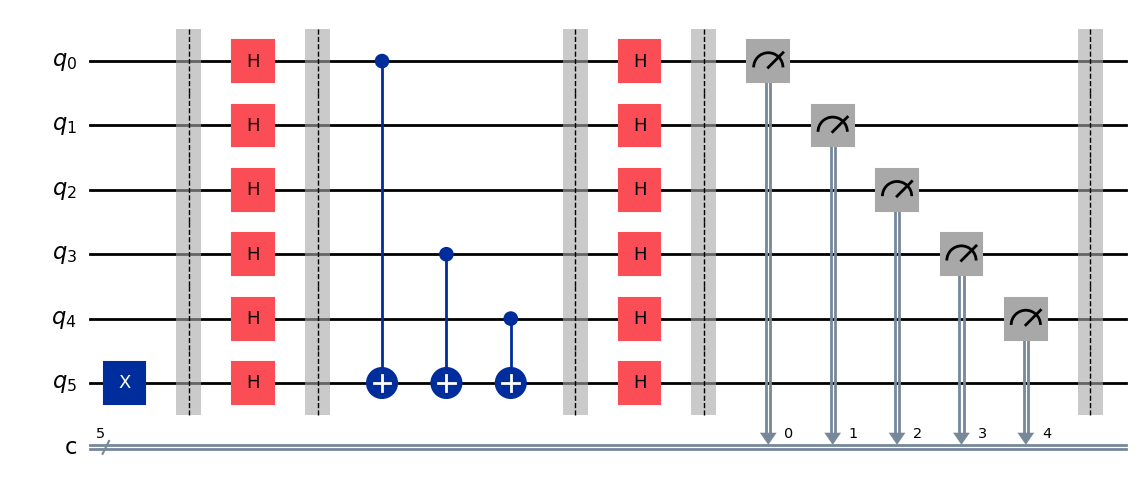

In [ ]:
qc.draw("mpl", filename="quantum_circuit.png")

In [ ]:
# Ejecutar en simulador
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print("Resultados:", counts)

Resultados: {'11001': 1024}


## Algoritmo Simon

Se implementa el algoritmo de Simon, cuyo objetivo es encontrar una cadena binaria secreta escondida en una función que presenta una simetría particular. A diferencia de algoritmo de Bernstein-Vazinari, donde la respuesta se obtiene directamente, en Simon se obtiene ecuaciones que deben satisfacer la cadena secreta. Repitiendo el proceso varias veces, es posible reconstruir esa cadena. Este algoritmo es especialmente importante porque introduce la idea de detectar estructuras ocultas en funciones, concepto fundamental en algortismos cuanticos mas avanzados.

Registro: es simplemente un grupo de qubits que cumplen una funcion especifica.

Primer registro (input)
* Son los primeros n qubits
* Representan el valor x
* Es donde creamos la superposicion

Segundo registro (output)
* Son otros n qubits
* Guardan el resultado de la funcion f(x)

Forma simple:

* Primer registro: preguntas x
* Segundo registro: respuestas f(x)

In [ ]:
#Importamos la liberias

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [ ]:
# Cadena secreta
s = "11"
n = len(s)

# En Simon usamos 2 registros de n qubits
# y n bits clásicos para medir el primer registro
qc = QuantumCircuit(2*n, n)

## En Simom ambos registros comienzan en |0>

Aplicamos Hadamard solo en el primer registro

In [ ]:
qc.h(range(n))
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(4, "q"), index=0>, <Qubit register=(4, "q"), index=1>, <Qubit register=(4, "q"), index=2>, <Qubit register=(4, "q"), index=3>), clbits=())

## Oraculo

In [ ]:
# Copiar input al output
for i in range(n):
    qc.cx(i, i+n)

# Introducir estructura de Simon usando s
for i, bit in enumerate(s):
    if bit == "1":
        qc.cx(0, i+n)

qc.barrier()


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(4, "q"), index=0>, <Qubit register=(4, "q"), index=1>, <Qubit register=(4, "q"), index=2>, <Qubit register=(4, "q"), index=3>), clbits=())

In [ ]:
 #Dibujar el circuito
print(qc.draw())

     ┌───┐ ░                      ░ 
q_0: ┤ H ├─░───■─────────■────■───░─
     ├───┤ ░   │         │    │   ░ 
q_1: ┤ H ├─░───┼────■────┼────┼───░─
     └───┘ ░ ┌─┴─┐  │  ┌─┴─┐  │   ░ 
q_2: ──────░─┤ X ├──┼──┤ X ├──┼───░─
           ░ └───┘┌─┴─┐└───┘┌─┴─┐ ░ 
q_3: ──────░──────┤ X ├─────┤ X ├─░─
           ░      └───┘     └───┘ ░ 
c: 2/═══════════════════════════════
                                    


## Medir el primer registro

In [ ]:
qc.measure(range(n), range(n))

In [ ]:
 #Dibujar el circuito
print(qc.draw())

     ┌───┐ ░                      ░ ┌─┐   
q_0: ┤ H ├─░───■─────────■────■───░─┤M├───
     ├───┤ ░   │         │    │   ░ └╥┘┌─┐
q_1: ┤ H ├─░───┼────■────┼────┼───░──╫─┤M├
     └───┘ ░ ┌─┴─┐  │  ┌─┴─┐  │   ░  ║ └╥┘
q_2: ──────░─┤ X ├──┼──┤ X ├──┼───░──╫──╫─
           ░ └───┘┌─┴─┐└───┘┌─┴─┐ ░  ║  ║ 
q_3: ──────░──────┤ X ├─────┤ X ├─░──╫──╫─
           ░      └───┘     └───┘ ░  ║  ║ 
c: 2/════════════════════════════════╩══╩═
                                     0  1 


In [ ]:
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print("Resultados:", counts)
print(qc.draw())

Resultados: {'10': 264, '00': 261, '01': 247, '11': 252}
     ┌───┐ ░                      ░ ┌─┐   
q_0: ┤ H ├─░───■─────────■────■───░─┤M├───
     ├───┤ ░   │         │    │   ░ └╥┘┌─┐
q_1: ┤ H ├─░───┼────■────┼────┼───░──╫─┤M├
     └───┘ ░ ┌─┴─┐  │  ┌─┴─┐  │   ░  ║ └╥┘
q_2: ──────░─┤ X ├──┼──┤ X ├──┼───░──╫──╫─
           ░ └───┘┌─┴─┐└───┘┌─┴─┐ ░  ║  ║ 
q_3: ──────░──────┤ X ├─────┤ X ├─░──╫──╫─
           ░      └───┘     └───┘ ░  ║  ║ 
c: 2/════════════════════════════════╩══╩═
                                     0  1 


Queremos llegar a la transformada QUANTICA DE FURIER

SIMON BASICO

In [ ]:
#Importamos la liberias

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [ ]:
# Definimos el circuito
qc_0= QuantumCircuit(4,4)


# Puerta NOT en el segundo qbit
#qc_0.x(1)
#qc_0.barrier()

# Aplicamos Hadamard en los primeros 2 QBITS
qc_0.h(0)
qc_0.h(1)
qc_0.barrier()

# ORACULO
qc_0.cx(0,2)
qc_0.cx(0,3)
qc_0.cx(1,2)
qc_0.cx(1,3)
qc_0.barrier()

#Medimos los ultimos 2 QBITS
qc_0.measure(3,3)
qc_0.measure(2,2)

# Hadamard en las 2 primeras lineas (de nuevo)
qc_0.h(0)
qc_0.h(1)
qc_0.barrier()

# Medición en las 2 primeras lineas
qc_0.measure(0,0)
qc_0.measure(1,1)

# Dibujamos el resultado
print(qc_0.draw())

     ┌───┐ ░                      ░ ┌───┐    ░ ┌─┐   
q_0: ┤ H ├─░───■────■─────────────░─┤ H ├────░─┤M├───
     ├───┤ ░   │    │             ░ ├───┤    ░ └╥┘┌─┐
q_1: ┤ H ├─░───┼────┼────■────■───░─┤ H ├────░──╫─┤M├
     └───┘ ░ ┌─┴─┐  │  ┌─┴─┐  │   ░ └───┘┌─┐ ░  ║ └╥┘
q_2: ──────░─┤ X ├──┼──┤ X ├──┼───░──────┤M├─░──╫──╫─
           ░ └───┘┌─┴─┐└───┘┌─┴─┐ ░  ┌─┐ └╥┘ ░  ║  ║ 
q_3: ──────░──────┤ X ├─────┤ X ├─░──┤M├──╫──░──╫──╫─
           ░      └───┘     └───┘ ░  └╥┘  ║  ░  ║  ║ 
c: 4/═════════════════════════════════╩═══╩═════╩══╩═
                                      3   2     0  1 


In [ ]:
filtered_counts = {}

for key, value in counts.items():
    # Extraer SOLO q1 y q0 (últimos 2 bits)
    first_register = key[-2:]

    if first_register in filtered_counts:
        filtered_counts[first_register] += value
    else:
        filtered_counts[first_register] = value

print("Primer registro:", filtered_counts)

Primer registro: {'11': 547, '00': 477}


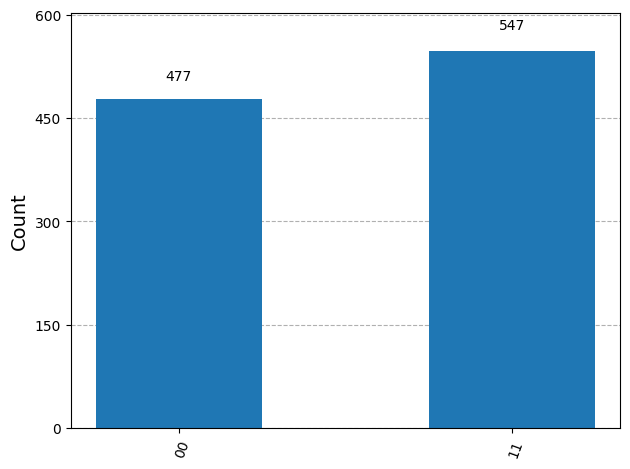

In [ ]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

fig = plot_histogram(filtered_counts)
display(fig)
plt.show()

PARA 3 QBITS

In [ ]:
# Definimos el circuito
qc_1= QuantumCircuit(6,6)


# Puerta NOT en el segundo qbit
#qc_0.x(1)
#qc_0.barrier()

# Aplicamos Hadamard en los primeros 3 QBITS

qc_1.h(0)
qc_1.h(1)
qc_1.h(2)
qc_1.barrier()

# ORACULO

qc_1.cx(0,3)
qc_1.cx(1,4)
qc_1.cx(2,5)
# SEGUNDO BLOCO
qc_1.cx(0,3)
qc_1.cx(0,5)
qc_1.barrier() #BARRERA

#MEDIMOS OS ULTIMOS 3 QBITS
qc_1.measure(3,3)
qc_1.measure(4,4)
qc_1.measure(5,5)
qc_1.barrier() #BARRERA

# HADAMARD EN LAS PRIMERAS 3 LINEAS
qc_1.h(0)
qc_1.h(1)
qc_1.h(2)
qc_1.barrier()

# MEDIMOS FINALMENTE AS 3 PRIMEIRAS LINHAS

qc_1.measure(0,0)
qc_1.measure(1,1)
qc_1.measure(2,2)

# Dibujamos el resultado
print(qc_1.draw())

     ┌───┐ ░                           ░           ░ ┌───┐ ░ ┌─┐      
q_0: ┤ H ├─░───■──────────────■────■───░───────────░─┤ H ├─░─┤M├──────
     ├───┤ ░   │              │    │   ░           ░ ├───┤ ░ └╥┘┌─┐   
q_1: ┤ H ├─░───┼────■─────────┼────┼───░───────────░─┤ H ├─░──╫─┤M├───
     ├───┤ ░   │    │         │    │   ░           ░ ├───┤ ░  ║ └╥┘┌─┐
q_2: ┤ H ├─░───┼────┼────■────┼────┼───░───────────░─┤ H ├─░──╫──╫─┤M├
     └───┘ ░ ┌─┴─┐  │    │  ┌─┴─┐  │   ░ ┌─┐       ░ └───┘ ░  ║  ║ └╥┘
q_3: ──────░─┤ X ├──┼────┼──┤ X ├──┼───░─┤M├───────░───────░──╫──╫──╫─
           ░ └───┘┌─┴─┐  │  └───┘  │   ░ └╥┘┌─┐    ░       ░  ║  ║  ║ 
q_4: ──────░──────┤ X ├──┼─────────┼───░──╫─┤M├────░───────░──╫──╫──╫─
           ░      └───┘┌─┴─┐     ┌─┴─┐ ░  ║ └╥┘┌─┐ ░       ░  ║  ║  ║ 
q_5: ──────░───────────┤ X ├─────┤ X ├─░──╫──╫─┤M├─░───────░──╫──╫──╫─
           ░           └───┘     └───┘ ░  ║  ║ └╥┘ ░       ░  ║  ║  ║ 
c: 6/═════════════════════════════════════╩══╩══╩═════════════╩══╩══╩═
      

  # ADAPTANDO

In [ ]:
simulator = AerSimulator()
result = simulator.run(qc_1, shots=1024).result()
counts = result.get_counts()

print("Resultados completos:", counts)

Resultados completos: {'000000': 70, '000101': 64, '100101': 58, '110101': 77, '000010': 68, '100111': 60, '100010': 59, '010111': 63, '110010': 59, '010010': 76, '010101': 56, '000111': 54, '110111': 65, '010000': 64, '110000': 66, '100000': 65}


In [ ]:
filtered_counts = {}

for key, value in counts.items():
    # Tomamos SOLO los 3 últimos bits → q2 q1 q0
    first_register = key[-3:]

    if first_register in filtered_counts:
        filtered_counts[first_register] += value
    else:
        filtered_counts[first_register] = value

print("Primer registro:", filtered_counts)

Primer registro: {'000': 265, '101': 255, '010': 262, '111': 242}


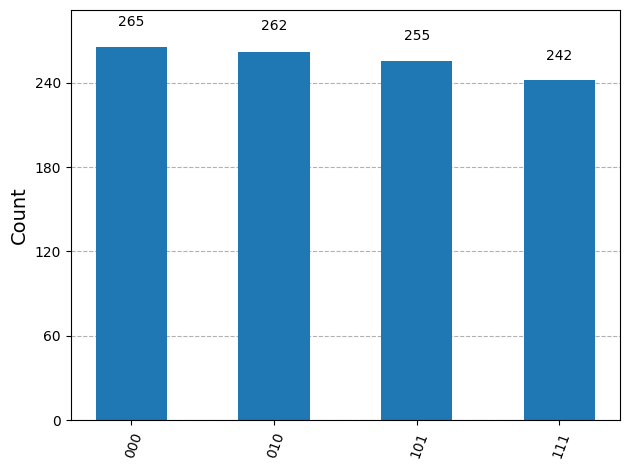

In [ ]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

fig = plot_histogram(filtered_counts)
display(fig)
plt.show()

In [ ]:
# Definimos el circuito
qc_2= QuantumCircuit(6,6)


# Puerta NOT en el segundo qbit
#qc_0.x(1)
#qc_0.barrier()

# Aplicamos Hadamard en los primeros 3 QBITS

qc_2.h(0)
qc_2.h(1)
qc_2.h(2)
qc_2.barrier()

# ORACULO

qc_2.cx(0,3)
qc_2.cx(1,4)
qc_2.cx(2,5)
# SEGUNDO BLOCO
qc_2.cx(0,3)
#qc_2.cx(0,5)
qc_2.barrier() #BARRERA

#MEDIMOS OS ULTIMOS 3 QBITS
qc_2.measure(3,3)
qc_2.measure(4,4)
qc_2.measure(5,5)
qc_2.barrier() #BARRERA

# HADAMARD EN LAS PRIMERAS 3 LINEAS
qc_2.h(0)
qc_2.h(1)
qc_2.h(2)
qc_2.barrier()

# MEDIMOS FINALMENTE AS 3 PRIMEIRAS LINHAS

qc_2.measure(0,0)
qc_2.measure(1,1)
qc_2.measure(2,2)

# Dibujamos el resultado
print(qc_2.draw())

     ┌───┐ ░                      ░           ░ ┌───┐ ░ ┌─┐      
q_0: ┤ H ├─░───■──────────────■───░───────────░─┤ H ├─░─┤M├──────
     ├───┤ ░   │              │   ░           ░ ├───┤ ░ └╥┘┌─┐   
q_1: ┤ H ├─░───┼────■─────────┼───░───────────░─┤ H ├─░──╫─┤M├───
     ├───┤ ░   │    │         │   ░           ░ ├───┤ ░  ║ └╥┘┌─┐
q_2: ┤ H ├─░───┼────┼────■────┼───░───────────░─┤ H ├─░──╫──╫─┤M├
     └───┘ ░ ┌─┴─┐  │    │  ┌─┴─┐ ░ ┌─┐       ░ └───┘ ░  ║  ║ └╥┘
q_3: ──────░─┤ X ├──┼────┼──┤ X ├─░─┤M├───────░───────░──╫──╫──╫─
           ░ └───┘┌─┴─┐  │  └───┘ ░ └╥┘┌─┐    ░       ░  ║  ║  ║ 
q_4: ──────░──────┤ X ├──┼────────░──╫─┤M├────░───────░──╫──╫──╫─
           ░      └───┘┌─┴─┐      ░  ║ └╥┘┌─┐ ░       ░  ║  ║  ║ 
q_5: ──────░───────────┤ X ├──────░──╫──╫─┤M├─░───────░──╫──╫──╫─
           ░           └───┘      ░  ║  ║ └╥┘ ░       ░  ║  ║  ║ 
c: 6/════════════════════════════════╩══╩══╩═════════════╩══╩══╩═
                                     3  4  5             0  1  2 


Resultados completos: {'010000': 62, '110000': 62, '100000': 61, '110100': 63, '000000': 71, '100110': 52, '000110': 58, '100100': 68, '000100': 71, '110110': 71, '010100': 54, '010010': 64, '110010': 68, '100010': 75, '000010': 72, '010110': 52}
Primer registro: {'000': 256, '100': 256, '110': 233, '010': 279}


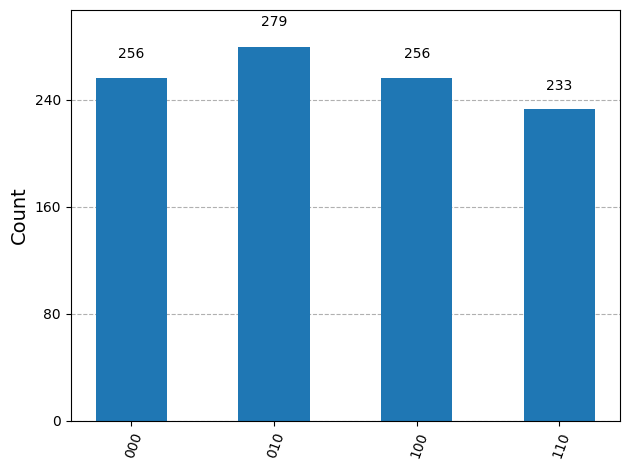

In [ ]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

simulator = AerSimulator()
result = simulator.run(qc_2, shots=1024).result()
counts = result.get_counts()

print("Resultados completos:", counts)

filtered_counts = {}

for key, value in counts.items():
    first_register = key[-3:]   # q2 q1 q0
    filtered_counts[first_register] = filtered_counts.get(first_register, 0) + value

print("Primer registro:", filtered_counts)

fig = plot_histogram(filtered_counts)
display(fig)
plt.show()

# PARA PERIODO 3

In [ ]:
#Importamos la liberias

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [ ]:
# Definimos el circuito
qc_3= QuantumCircuit(6,6)


# Puerta NOT en el segundo qbit
#qc_0.x(1)
#qc_0.barrier()

# Aplicamos Hadamard en los primeros 3 QBITS

qc_3.h(0)
qc_3.h(1)
qc_3.h(2)
qc_3.barrier()

# ORACULO

qc_3.cx(0,3)
qc_3.cx(1,4)
qc_3.cx(2,5)
qc_3.barrier() #BARRERA
# SEGUNDO BLOCO
qc_3.cx(1,4)
qc_3.cx(1,5)
qc_3.barrier() #BARRERA

#MEDIMOS OS ULTIMOS 3 QBITS
qc_3.measure(3,3)
qc_3.measure(4,4)
qc_3.measure(5,5)
qc_3.barrier() #BARRERA

# HADAMARD EN LAS PRIMERAS 3 LINEAS
qc_3.h(0)
qc_3.h(1)
qc_3.h(2)
qc_3.barrier()

# MEDIMOS FINALMENTE AS 3 PRIMEIRAS LINHAS

qc_3.measure(0,0)
qc_3.measure(1,1)
qc_3.measure(2,2)

# Dibujamos el resultado
print(qc_3.draw())

     ┌───┐ ░                 ░            ░           ░ ┌───┐ ░ ┌─┐      
q_0: ┤ H ├─░───■─────────────░────────────░───────────░─┤ H ├─░─┤M├──────
     ├───┤ ░   │             ░            ░           ░ ├───┤ ░ └╥┘┌─┐   
q_1: ┤ H ├─░───┼────■────────░───■────■───░───────────░─┤ H ├─░──╫─┤M├───
     ├───┤ ░   │    │        ░   │    │   ░           ░ ├───┤ ░  ║ └╥┘┌─┐
q_2: ┤ H ├─░───┼────┼────■───░───┼────┼───░───────────░─┤ H ├─░──╫──╫─┤M├
     └───┘ ░ ┌─┴─┐  │    │   ░   │    │   ░ ┌─┐       ░ └───┘ ░  ║  ║ └╥┘
q_3: ──────░─┤ X ├──┼────┼───░───┼────┼───░─┤M├───────░───────░──╫──╫──╫─
           ░ └───┘┌─┴─┐  │   ░ ┌─┴─┐  │   ░ └╥┘┌─┐    ░       ░  ║  ║  ║ 
q_4: ──────░──────┤ X ├──┼───░─┤ X ├──┼───░──╫─┤M├────░───────░──╫──╫──╫─
           ░      └───┘┌─┴─┐ ░ └───┘┌─┴─┐ ░  ║ └╥┘┌─┐ ░       ░  ║  ║  ║ 
q_5: ──────░───────────┤ X ├─░──────┤ X ├─░──╫──╫─┤M├─░───────░──╫──╫──╫─
           ░           └───┘ ░      └───┘ ░  ║  ║ └╥┘ ░       ░  ║  ║  ║ 
c: 6/═════════════════════════════════

In [ ]:
simulator = AerSimulator()
result = simulator.run(qc_3, shots=1024).result()
counts = result.get_counts()

print("Resultados completos:", counts)

Resultados completos: {'000111': 57, '101001': 65, '101110': 68, '001001': 63, '101000': 71, '000001': 58, '001111': 64, '000000': 66, '100110': 51, '100000': 72, '100111': 62, '100001': 61, '001110': 62, '000110': 67, '001000': 67, '101111': 70}


In [ ]:
simulator = AerSimulator()
result = simulator.run(qc_3, shots=1024).result()
counts = result.get_counts()


In [ ]:
filtered_counts = {}

for key, value in counts.items():
    # Tomamos SOLO los 3 últimos bits → q2 q1 q0
    first_register = key[-3:]

    if first_register in filtered_counts:
        filtered_counts[first_register] += value
    else:
        filtered_counts[first_register] = value

print("Primer registro:", filtered_counts)

Primer registro: {'110': 262, '001': 244, '000': 273, '111': 245}


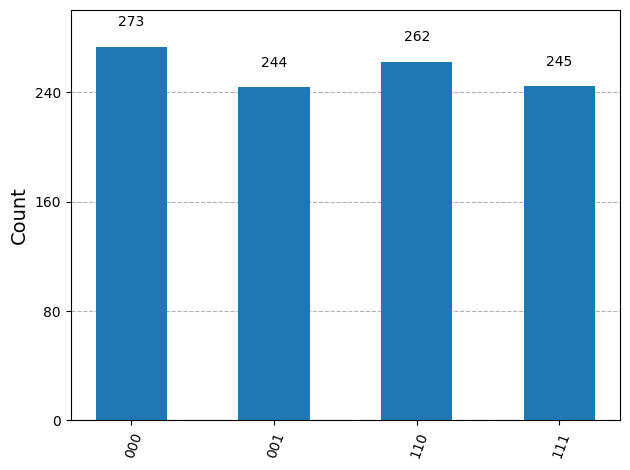

In [ ]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

fig = plot_histogram(filtered_counts)
display(fig)
plt.show()

## TEST

In [ ]:
# Definimos el circuito
qc_4= QuantumCircuit(6,6)


# Puerta NOT en el segundo qbit
#qc_0.x(1)
#qc_0.barrier()

# Aplicamos Hadamard en los primeros 3 QBITS

qc_4.h(0)
qc_4.h(1)
qc_4.h(2)
qc_4.barrier()

# ORACULO

qc_4.cx(0,3)
qc_4.cx(1,4)
qc_4.cx(2,5)
qc_4.barrier() #BARRERA
# SEGUNDO BLOCO
qc_4.cx(2,4)
qc_4.cx(2,5)
qc_4.barrier() #BARRERA

#MEDIMOS OS ULTIMOS 3 QBITS
qc_4.measure(3,3)
qc_4.measure(4,4)
qc_4.measure(5,5)
qc_4.barrier() #BARRERA

# HADAMARD EN LAS PRIMERAS 3 LINEAS
qc_4.h(0)
qc_4.h(1)
qc_4.h(2)
qc_4.barrier()

# MEDIMOS FINALMENTE AS 3 PRIMEIRAS LINHAS

qc_4.measure(0,0)
qc_4.measure(1,1)
qc_4.measure(2,2)

# Dibujamos el resultado
print(qc_4.draw())

     ┌───┐ ░                 ░            ░           ░ ┌───┐ ░ ┌─┐      
q_0: ┤ H ├─░───■─────────────░────────────░───────────░─┤ H ├─░─┤M├──────
     ├───┤ ░   │             ░            ░           ░ ├───┤ ░ └╥┘┌─┐   
q_1: ┤ H ├─░───┼────■────────░────────────░───────────░─┤ H ├─░──╫─┤M├───
     ├───┤ ░   │    │        ░            ░           ░ ├───┤ ░  ║ └╥┘┌─┐
q_2: ┤ H ├─░───┼────┼────■───░───■────■───░───────────░─┤ H ├─░──╫──╫─┤M├
     └───┘ ░ ┌─┴─┐  │    │   ░   │    │   ░ ┌─┐       ░ └───┘ ░  ║  ║ └╥┘
q_3: ──────░─┤ X ├──┼────┼───░───┼────┼───░─┤M├───────░───────░──╫──╫──╫─
           ░ └───┘┌─┴─┐  │   ░ ┌─┴─┐  │   ░ └╥┘┌─┐    ░       ░  ║  ║  ║ 
q_4: ──────░──────┤ X ├──┼───░─┤ X ├──┼───░──╫─┤M├────░───────░──╫──╫──╫─
           ░      └───┘┌─┴─┐ ░ └───┘┌─┴─┐ ░  ║ └╥┘┌─┐ ░       ░  ║  ║  ║ 
q_5: ──────░───────────┤ X ├─░──────┤ X ├─░──╫──╫─┤M├─░───────░──╫──╫──╫─
           ░           └───┘ ░      └───┘ ░  ║  ║ └╥┘ ░       ░  ║  ║  ║ 
c: 6/═════════════════════════════════

In [ ]:
simulator = AerSimulator()
result = simulator.run(qc_4, shots=1024).result()
counts = result.get_counts()

print("Resultados completos:", counts)

Resultados completos: {'000111': 64, '011110': 73, '010000': 56, '000000': 67, '011001': 72, '001000': 49, '000110': 60, '010111': 81, '000001': 60, '001111': 65, '010110': 66, '001001': 60, '010001': 48, '001110': 69, '011000': 64, '011111': 70}


In [ ]:
filtered_counts = {}

for key, value in counts.items():
    # Tomamos SOLO los 3 últimos bits → q2 q1 q0
    first_register = key[-3:]

    if first_register in filtered_counts:
        filtered_counts[first_register] += value
    else:
        filtered_counts[first_register] = value

print("Primer registro:", filtered_counts)

Primer registro: {'111': 280, '110': 268, '000': 236, '001': 240}


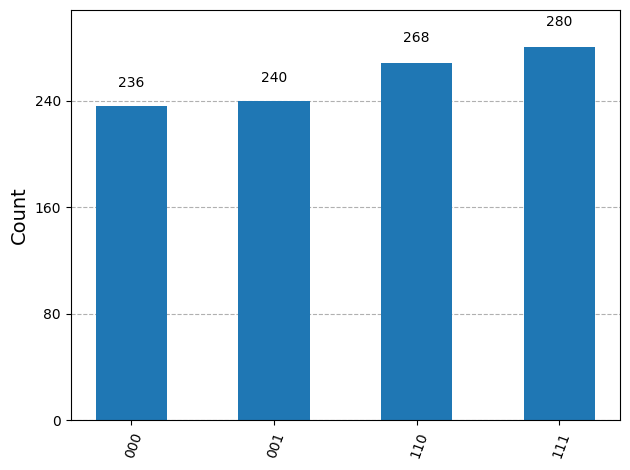

In [ ]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

fig = plot_histogram(filtered_counts)
display(fig)
plt.show()